<a href="https://colab.research.google.com/github/DanielVincentIon/loan-approval-ml-model/blob/main/loan_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# This section imports the Python libraries required for data handling, visualisation, preprocessing, model training, and evaluation. #
# Pandas and NumPy are used for data manipulation. Matplotlib and Seaborn support data visualisation. Scikit-learn provides tools for splitting the dataset, preprocessing features, training classification models, and evaluating model performance. #

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [4]:
# This section loads the dataset into a pandas dataframe directly from a GitHub repository. This allows the data to be inspected and prepared for preprocessing and modelling. #

url = "https://raw.githubusercontent.com/DanielVincentIon/loan-approval-ml-model/main/data/loan_data.csv"

df = pd.read_csv(url)
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [5]:
# This section explores the structure of the dataset, identifies variable types, and checks for issues such as missing values and class imbalance #

df.info()
df.describe()
df['loan_status'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

,count
loan_status,
0,35000
1,10000


In [6]:
# This section transforms categorical variables into numerical form using one-hot encoding, allowing them to be used by classification algorithms. The dataset is then checked to confirm that all features are in a suitable format #

df = pd.get_dummies(df, drop_first=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 23 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   person_age                          45000 non-null  float64
 1   person_income                       45000 non-null  float64
 2   person_emp_exp                      45000 non-null  int64  
 3   loan_amnt                           45000 non-null  float64
 4   loan_int_rate                       45000 non-null  float64
 5   loan_percent_income                 45000 non-null  float64
 6   cb_person_cred_hist_length          45000 non-null  float64
 7   credit_score                        45000 non-null  int64  
 8   loan_status                         45000 non-null  int64  
 9   person_gender_male                  45000 non-null  bool   
 10  person_education_Bachelor           45000 non-null  bool   
 11  person_education_Doctorate          45000

In [7]:
# This section separates the dataset into predictor variables (X) and the target variable (y), with loan_status representing the outcome to be predicted #

X = df.drop('loan_status', axis=1)
y = df['loan_status']

In [8]:
# This section splits the dataset into training and test sets using an 80/20 ratio. The training data is used to fit the model, while the test data is reserved for evaluating performance on unseen data. A fixed random state is used to ensure reproducibility of the results #

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
# This section standardises the numerical features using a StandardScaler to ensure that all variables are on a comparable scale. The scaler is fitted on the training data and then applied to both the training and test sets to prevent data leakage #

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
# This section trains a Logistic Regression model using the scaled training data #

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [11]:
# This section trains a Random Forest classifier using the training data #

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

In [12]:
# This section evaluates the performance of both models on the test dataset using classification metrics including precision, recall, and F1-score. These metrics provide a more complete assessment than accuracy alone #

y_pred_lr = lr.predict(X_test_scaled)
y_pred_rf = rf.predict(X_test)

print("Logistic Regression:")
print(classification_report(y_test, y_pred_lr))

print("Random Forest:")
print(classification_report(y_test, y_pred_rf))

Logistic Regression:
              precision    recall  f1-score   support

           0       0.93      0.94      0.93      6990
           1       0.78      0.74      0.76      2010

    accuracy                           0.89      9000
   macro avg       0.85      0.84      0.85      9000
weighted avg       0.89      0.89      0.89      9000

Random Forest:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96      6990
           1       0.90      0.77      0.83      2010

    accuracy                           0.93      9000
   macro avg       0.92      0.87      0.89      9000
weighted avg       0.93      0.93      0.93      9000



In [14]:
# This section examines the distribution of the target variable (loan_status) to assess class balance within the dataset. Identifying imbalances is important, as it may influence model performance and the choice of evaluation metrics #

df['loan_status'].value_counts()

,count
loan_status,
0,35000
1,10000


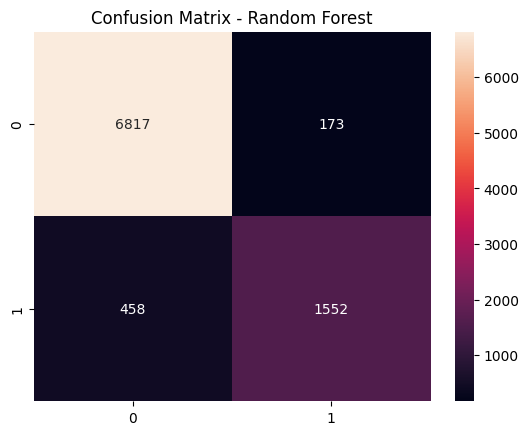

In [13]:
# This section uses a confusion matrix to visualise the Random Forest's model classification performance and identify the types of errors made on unseen data #

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [16]:
feature_importances = pd.Series(rf.feature_importances_, index=X.columns)
feature_importances.sort_values(ascending=False).head(10)

,0
previous_loan_defaults_on_file_Yes,0.221587
loan_percent_income,0.169472
loan_int_rate,0.155439
person_income,0.122609
loan_amnt,0.059422
credit_score,0.055568
person_home_ownership_RENT,0.052719
person_age,0.031634
person_emp_exp,0.028661
cb_person_cred_hist_length,0.025398
